In [10]:
from utils import load_raw_data   # import the raw (uncleaned) loader specifically

import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = load_raw_data("data.csv")

In [13]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 80765 rows, 18 columns


In [14]:
df.head()

,training_date,id,reg_year,plate_age_id,year_plate_start_date,mileage,advertised_price,at_derivative_id,make,model,generation,fuel,engine,body,transmission,trim,doors,list_price
0,2023-06-01,e79c9066f50e136b5ab14bb39996a62b,2009,9,2009-03-01,83000,5290,ff04b6482e3e4eaf9af497526d99f874,Mercedes-Benz,SLK,Convertible (2008 - 2011),Petrol,1.8,Convertible,Automatic,NaN,2,31986.0
1,2023-06-01,3314e91aaa6e5d8adfec7266ae7f9ece,2009,9,2009-03-01,85900,9500,cb37d7493efd45b4a172b20258b3d323,BMW,X5,SUV (2006 - 2014),Diesel,3.0,SUV,Automatic,M Sport,5,48444.0
2,2023-06-01,36350752d23f19eb8eb3d3f545b2633f,2009,9,2009-03-01,114000,4490,85e0026201a141d4b68d07dfd1fe2141,Volvo,XC70,Estate (2007 - 2013) MK 2,Diesel,2.4,Estate,Manual,SE,5,30146.0
3,2023-06-01,dada9107064ba35a5570b939d2861f97,2009,9,2009-03-01,24900,3829,8f1339f38bab4f0aa8f194963e38e905,Suzuki,Alto,Hatchback (2009 - 2015) MK 6,Petrol,1.0,Hatchback,Manual,SZ3,5,7891.0
4,2023-06-01,32d056600b4346d9ddd96775fb6cf926,2009,9,2009-03-01,99000,2995,22be473a397e4641a3ba52ea1d4be819,Mazda,Mazda3,Hatchback (2009 - 2013),Petrol,1.6,Hatchback,Manual,Sport,5,17370.0


In [15]:
df.dtypes

training_date                str
id                           str
reg_year                   int64
plate_age_id               int64
year_plate_start_date        str
mileage                    int64
advertised_price           int64
at_derivative_id             str
make                         str
model                        str
generation                   str
fuel                         str
engine                   float64
body                         str
transmission                 str
trim                         str
doors                      int64
list_price               float64
dtype: object

In [17]:
# Count missing values per column
missing = df.isnull().sum()

# Convert to percentage of total rows, easier to judge severity at a glance
missing_pct = (missing / len(df)) * 100

# Combine into one table, sorted worst-first
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_summary

,missing_count,missing_pct
engine,3281,4.06
trim,2521,3.12
id,0,0.00
training_date,0,0.00
reg_year,0,0.00
plate_age_id,0,0.00
advertised_price,0,0.00
at_derivative_id,0,0.00
year_plate_start_date,0,0.00
mileage,0,0.00


In [18]:
# List the categorical columns we'll eventually need to encode
categorical_cols = ['make', 'model', 'generation', 'fuel', 'engine', 
                     'body', 'transmission', 'trim', 'plate_age_id', 
                     'at_derivative_id']

# Print the number of DISTINCT values per categorical column
# This tells us cardinality — directly affects which encoders are viable per column
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

make: 63 unique values
model: 676 unique values
generation: 841 unique values
fuel: 8 unique values
engine: 54 unique values
body: 7 unique values
transmission: 2 unique values
trim: 1520 unique values
plate_age_id: 30 unique values
at_derivative_id: 19841 unique values


In [19]:
# For each categorical column, print the 15 most frequent values
# Helps spot inconsistent formatting (e.g. "Automatic" vs "automatic")
# or placeholder values hiding as a category (e.g. "Unknown", "-")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- make ---
make
Ford             7426
Audi             6806
BMW              6614
Volkswagen       6522
Mercedes-Benz    6190
Vauxhall         4999
Land Rover       3489
Toyota           3426
Nissan           3324
Kia              2977
Peugeot          2826
Hyundai          2398
MINI             2346
SKODA            2147
Volvo            1991
Name: count, dtype: int64

--- model ---
model
Fiesta      2538
Golf        2254
Focus       1897
Corsa       1594
A Class     1591
1 Series    1312
C Class     1293
3 Series    1290
Hatch       1263
Qashqai     1205
A3          1078
Polo        1035
500         1000
Juke         961
Sportage     957
Name: count, dtype: int64

--- generation ---
generation
SUV (2019 - )              3368
SUV (2017 - 2021)          2762
Hatchback (2019 - )        2252
Hatchback (2017 - 2020)    2219
Hatchback (2017 - 2021)    2150
SUV (2020 - )              2097
Hatchback (2020 - )        1992
SUV (2016 - 2020)          1883
SUV (2018 - )              1862
Hatc

In [20]:
# Specifically check whether 'engine' is missing ONLY for electric vehicles
# (as the schema suggested — engine size isn't applicable to EVs)
# This confirms whether the missingness is structural/explainable rather than random
df.groupby('fuel')['engine'].apply(lambda x: x.isnull().sum())

fuel
Bi Fuel                     0
Diesel                      0
Diesel Hybrid               0
Diesel Plug-in Hybrid       0
Electric                 3220
Petrol                      0
Petrol Hybrid               0
Petrol Plug-in Hybrid      61
Name: engine, dtype: int64

In [21]:
# Summary statistics for the target variable (advertised_price)
# Useful for spotting obvious data errors (e.g. price of £0, or extreme outliers)
df['advertised_price'].describe()

count    8.076500e+04
mean     2.127082e+04
std      2.280572e+04
min      6.950000e+02
25%      1.049500e+04
50%      1.699000e+04
75%      2.449900e+04
max      1.195000e+06
Name: advertised_price, dtype: float64

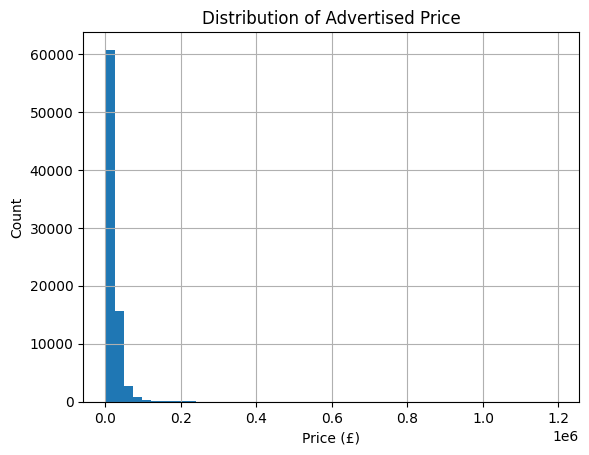

In [22]:
# Visualise the distribution of advertised_price
df['advertised_price'].hist(bins=50)
plt.title('Distribution of Advertised Price')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()